# LQG (Kalman + LQR) on a Noisy Double Integrator

This notebook simulates a point-mass with process and measurement noise.

We use a **Kalman filter** to estimate state from noisy position, and **LQR** on the estimate to control.

We can change `sigma_a`, `sigma_y`, `Q`, and `R` to see responsiveness vs. smoothness trade-offs.


## The situation

You’re driving a car (our system) but:

* You only have a **noisy GPS** that tells you position (sometimes off by a few meters).
* You can’t measure velocity directly.
* The road has **random bumps** (unpredictable accelerations).

Goal: bring the car to the destination (position = 0, stopped) using the pedal (control input), while being smart about noise.

## The model (physics of the car)

* **State:** $[p, v]$ = position, velocity.
* **Input:** $u$ = acceleration (pedal).
* **A:** says how the car “coasts” each step (position advances by velocity × time, velocity stays the same).
* **B:** says how much pressing the pedal changes position and velocity.
* **C:** says what the sensor measures (just position, not velocity).

### The noises

* **Process noise (σₐ):** random bumps in the road (unmodeled acceleration).
* **Measurement noise (σᵧ):** GPS jitter (noisy sensor).

### The brains

* **Kalman filter:** your navigator—takes noisy GPS + physics model, and gives best guesses of position *and* velocity.
* **LQR:** your reflexes—decides how hard to press the pedal given your guess of where you are and how fast you’re moving.

Put together, this is **LQG**: navigate with noisy sensors and drive optimally.

## What the notebook does, step by step

1. **Simulate the world**

   * Start 8 meters away from the goal, stopped.
   * Add random bumps (σₐ) each step.
   * Add GPS noise (σᵧ) to position measurements.

2. **Set your preferences**

   * `Q = diag([5,1])`: “I care about position a lot, velocity somewhat.”
   * `R = [[0.3]]`: “I don’t want to slam the pedal too hard.”

3. **Compute your reflex rule** (LQR)

   * The Riccati math finds `K = [3.75, 3.21]`.
   * Translation: *for each meter off target, push with strength 3.75; for each m/s of velocity, push with strength 3.21.*

4. **Estimate state (Kalman filter)**

   * Each step, take GPS reading.
   * Compare to predicted position → compute **innovation** (GPS – predicted).
   * Blend model and GPS with optimal gain → get new estimates of position and velocity.

5. **Control the car**

   * Compute `u = -K @ x_hat` (reflex on the estimate).
   * Apply it to the car.
   * Repeat the loop.

6. **Plot results**

   * **Position:** Orange = true, Blue = noisy GPS, Green = estimate (Kalman). Notice green hugs orange nicely while ignoring GPS jitter.
   * **Velocity:** Orange = true, Green = estimate (inferred from position changes).
   * **Control:** Big nudge at start, then smaller corrections.
   * **NIS (innovation diagnostic):** Checks if filter is consistent. Values bounce around but should hover near 1 on average.


## How to interpret the knobs

* **σᵧ bigger (noisier GPS):** Kalman filter trusts the model more → smoother estimates, controller reacts more slowly.
* **σₐ bigger (wigglier world):** Filter trusts the GPS more → reacts faster, control gets twitchier.
* **Q bigger (especially position weight):** Controller pushes harder to reach the goal quickly.
* **R bigger:** Controller is gentler, slower to act.


## The takeaway

* **Kalman filter** turns noisy GPS into reliable position *and velocity* estimates.
* **LQR** gives the smartest way to push the pedal based on those estimates.
* Together (**LQG**), you can control a car with only noisy sensors and random bumps, and still smoothly reach the goal.


/var/folders/pn/y6zh5gpn3rs_kj7p71jpmybh0000gn/T/ipykernel_73675/4089098389.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_meas[0] = (C @ x_true[:, 0]) + w[0]
/var/folders/pn/y6zh5gpn3rs_kj7p71jpmybh0000gn/T/ipykernel_73675/4089098389.py:76: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_meas[t] = (C @ x_true[:, t]) + w[t]


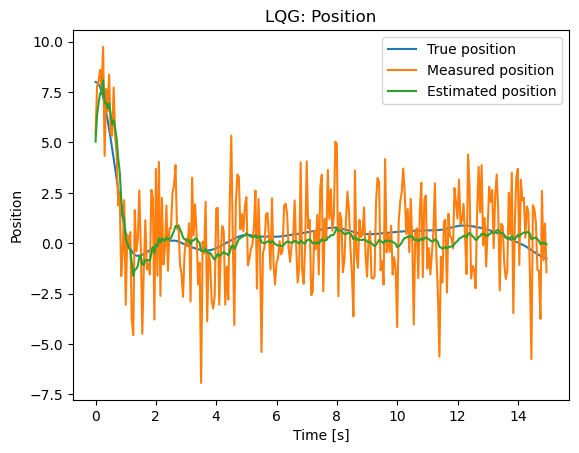

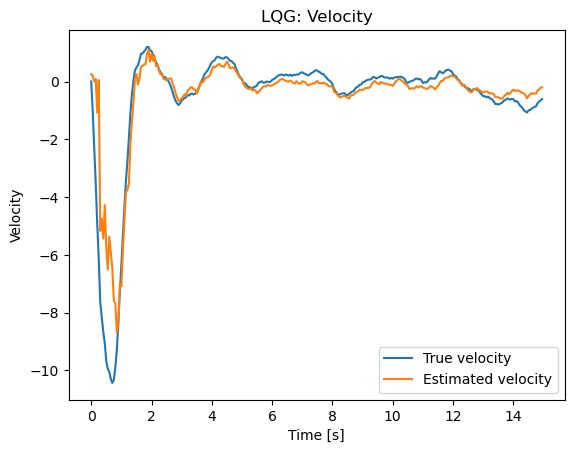

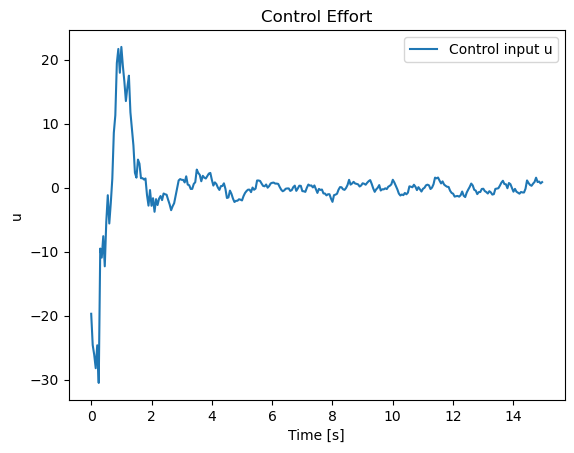

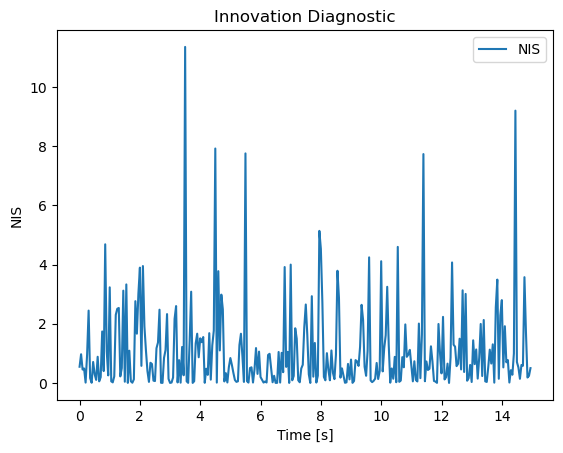

LQR gain K =
 [[3.75078164 3.21173409]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class CVParams:
    dt: float = 0.05
    T: int = 300
    sigma_a: float = 0.6
    sigma_y: float = 2.0

def double_integrator(dt: float):
    A = np.array([[1.0, dt],
                  [0.0, 1.0]])
    B = np.array([[0.5 * dt**2],
                  [dt]])
    C = np.array([[1.0, 0.0]])
    return A, B, C

class KFParams:
    def __init__(self, A,B,C,Q,R,x0,P0):
        self.A, self.B, self.C, self.Q, self.R, self.x0, self.P0 = A,B,C,Q,R,x0,P0

def kalman_predict_update(y_t, u_prev, x_hat_prev, P_prev, pars: KFParams):
    x_pred = pars.A @ x_hat_prev + pars.B @ u_prev
    P_pred = pars.A @ P_prev @ pars.A.T + pars.Q
    innov = y_t - pars.C @ x_pred
    S = pars.C @ P_pred @ pars.C.T + pars.R
    K = P_pred @ pars.C.T @ np.linalg.inv(S)
    x_filt = x_pred + K @ innov
    I = np.eye(pars.A.shape[0])
    P_filt = (I - K @ pars.C) @ P_pred @ (I - K @ pars.C).T + K @ pars.R @ K.T
    return x_pred, P_pred, K, innov, S, x_filt, P_filt

def dare_iterative(A, B, Q, R, max_iters=5000, tol=1e-10):
    P = Q.copy()
    for _ in range(max_iters):
        BT_P = B.T @ P
        S = R + BT_P @ B
        P_next = A.T @ P @ A - A.T @ P @ B @ np.linalg.inv(S) @ BT_P @ A + Q
        if np.linalg.norm(P_next - P, ord='fro') < tol:
            P = P_next
            break
        P = P_next
    K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)
    return P, K

def run_lqg(params: CVParams):
    A, B, C = double_integrator(params.dt)
    rng = np.random.default_rng(123)
    a_noise = rng.normal(0.0, params.sigma_a, size=params.T)
    w = rng.normal(0.0, params.sigma_y, size=params.T)
    x_true = np.zeros((2, params.T))
    y_meas = np.zeros(params.T)
    x_true[:, 0] = np.array([8.0, 0.0])
    y_meas[0] = (C @ x_true[:, 0]) + w[0]
    dt = params.dt
    Qk = (params.sigma_a**2) * np.array([[0.25*dt**4, 0.5*dt**3],
                                         [0.5*dt**3,      dt**2]])
    Rk = np.array([[params.sigma_y**2]])
    Qc = np.diag([5.0, 1.0])
    Rc = np.array([[0.3]])
    P_lqr, K = dare_iterative(A, B, Qc, Rc)
    kf_pars = KFParams(A,B,C,Qk,Rk,x0=np.array([0.0,0.0]),P0=np.diag([50.0,50.0]))
    x_hat = np.zeros((2, params.T))
    u_hist = np.zeros(params.T)
    innov = np.zeros(params.T)
    S_hist = np.zeros(params.T)
    x_pred, P_pred, K_gain, innov0, S0, x_filt, P_filt = kalman_predict_update(y_meas[0], np.array([0.0]), kf_pars.x0, kf_pars.P0, kf_pars)
    x_hat[:,0] = x_filt
    innov[0] = innov0.item(); S_hist[0] = S0.item()
    for t in range(1, params.T):
        u = - (K @ x_hat[:, t-1]).item()
        u_hist[t-1] = u
        x_true[:, t] = A @ x_true[:, t-1] + B.flatten()*u + B.flatten()*a_noise[t-1]
        y_meas[t] = (C @ x_true[:, t]) + w[t]
        x_pred, P_pred, K_gain, inn, Sval, x_filt, P_filt = kalman_predict_update(y_meas[t], np.array([u]), x_hat[:, t-1], P_filt, kf_pars)
        x_hat[:, t] = x_filt
        innov[t] = inn.item(); S_hist[t] = Sval.item()
    u_hist[-1] = - (K @ x_hat[:, -1]).item()
    return K, x_true, x_hat, y_meas, u_hist, innov, S_hist, params

K, x_true, x_hat, y_meas, u_hist, innov, S_hist, params = run_lqg(CVParams())
t = np.arange(params.T) * params.dt
plt.figure(); plt.plot(t, x_true[0], label='True position'); plt.plot(t, y_meas, label='Measured position'); plt.plot(t, x_hat[0], label='Estimated position'); plt.xlabel('Time [s]'); plt.ylabel('Position'); plt.title('LQG: Position'); plt.legend(); plt.show()
plt.figure(); plt.plot(t, x_true[1], label='True velocity'); plt.plot(t, x_hat[1], label='Estimated velocity'); plt.xlabel('Time [s]'); plt.ylabel('Velocity'); plt.title('LQG: Velocity'); plt.legend(); plt.show()
plt.figure(); plt.plot(t, u_hist, label='Control input u'); plt.xlabel('Time [s]'); plt.ylabel('u'); plt.title('Control Effort'); plt.legend(); plt.show()
nis = innov**2 / S_hist
plt.figure(); plt.plot(t, nis, label='NIS'); plt.xlabel('Time [s]'); plt.ylabel('NIS'); plt.title('Innovation Diagnostic'); plt.legend(); plt.show()
print('LQR gain K =\n', K)
